In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mengatur gaya visualisasi seaborn
sns.set_theme(style="whitegrid")

# Memuat dataset factory_production.csv
df = pd.read_csv('factory_production.csv')

# Menampilkan 10 baris pertama
df.head(10)

,Tanggal,Shift,Mesin,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
0,2025-11-01,Pagi,A,376,6,9.9,80.3,55.3
1,2025-11-01,Pagi,B,351,4,54.4,82.1,35.4
2,2025-11-01,Pagi,C,395,8,2.0,72.8,55.2
3,2025-11-01,Pagi,D,466,6,20.3,70.4,54.6
4,2025-11-01,Siang,A,339,3,3.2,70.0,51.9
5,2025-11-01,Siang,B,224,2,11.6,79.4,49.9
6,2025-11-01,Siang,C,294,8,5.7,85.7,68.4
7,2025-11-01,Siang,D,353,10,4.6,80.6,46.7
8,2025-11-01,Malam,A,254,10,10.0,91.1,59.6
9,2025-11-01,Malam,B,231,6,1.8,79.4,63.9


In [3]:
# Inspeksi struktur tipe data dan memori
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tanggal           1080 non-null   str    
 1   Shift             1080 non-null   str    
 2   Mesin             1080 non-null   str    
 3   Jumlah_Produksi   1080 non-null   int64  
 4   Jumlah_Cacat      1080 non-null   int64  
 5   Downtime (menit)  1059 non-null   float64
 6   Suhu_Mesin        1048 non-null   float64
 7   Kelembaban        1037 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 84.2 KB


In [4]:
# Ringkasan statistik deskriptif data numerik
df.describe()

,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
count,1080.000000,1080.000000,1059.000000,1048.000000,1037.000000
mean,349.600000,7.934259,15.110009,76.951718,49.857281
std,59.510571,4.416073,15.214485,8.218287,10.178976
min,142.000000,0.000000,0.000000,55.000000,25.000000
25%,311.000000,5.000000,4.300000,70.900000,42.900000
50%,349.000000,7.000000,10.800000,77.100000,49.900000
75%,390.250000,10.000000,20.200000,82.500000,56.800000
max,528.000000,42.000000,110.300000,104.900000,79.200000


In [5]:
# Pengecekan jumlah missing value pada setiap kolom
df.isnull().sum()

Tanggal              0
Shift                0
Mesin                0
Jumlah_Produksi      0
Jumlah_Cacat         0
Downtime (menit)    21
Suhu_Mesin          32
Kelembaban          43
dtype: int64

In [7]:
df_clean = df.copy()

df_clean['Downtime (menit)'] = df_clean['Downtime (menit)'].fillna(
    df_clean['Downtime (menit)'].median()
)

df_clean['Suhu_Mesin'] = df_clean['Suhu_Mesin'].fillna(
    df_clean['Suhu_Mesin'].median()
)

df_clean['Kelembaban'] = df_clean['Kelembaban'].fillna(
    df_clean['Kelembaban'].median()
)

In [8]:
df.isnull().sum()

Tanggal              0
Shift                0
Mesin                0
Jumlah_Produksi      0
Jumlah_Cacat         0
Downtime (menit)    21
Suhu_Mesin          32
Kelembaban          43
dtype: int64

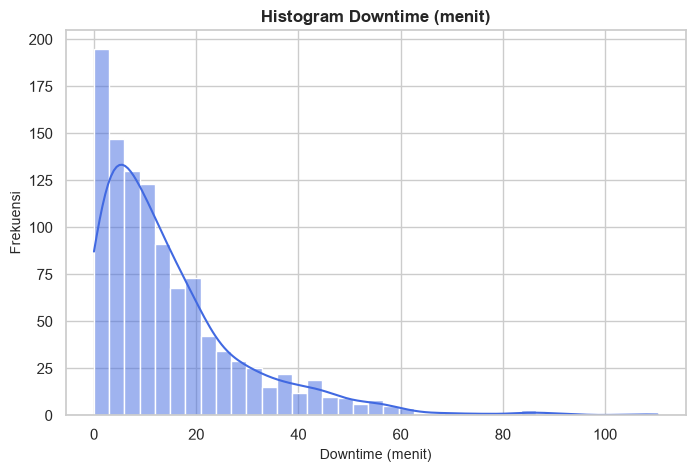

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Downtime (menit)'], kde=True, color='royalblue')
plt.title('Histogram Downtime (menit)', fontsize=12, fontweight='bold')
plt.xlabel('Downtime (menit)', fontsize=10)
plt.ylabel('Frekuensi', fontsize=10)
plt.show()

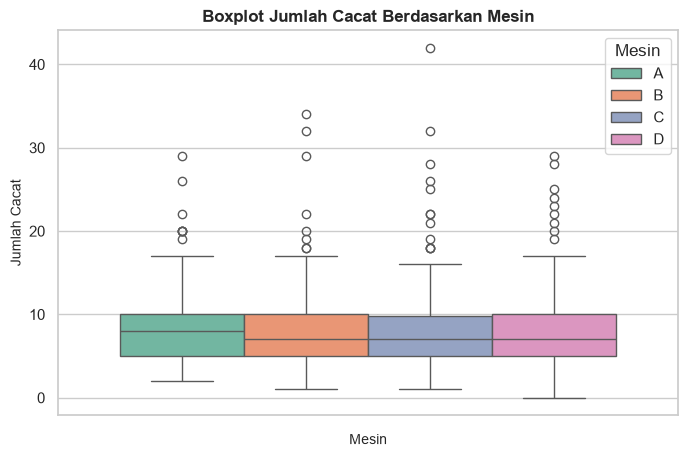

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, hue='Mesin', y='Jumlah_Cacat', palette='Set2')
plt.title('Boxplot Jumlah Cacat Berdasarkan Mesin', fontsize=12, fontweight='bold')
plt.xlabel('Mesin', fontsize=10)
plt.ylabel('Jumlah Cacat', fontsize=10)
plt.show()

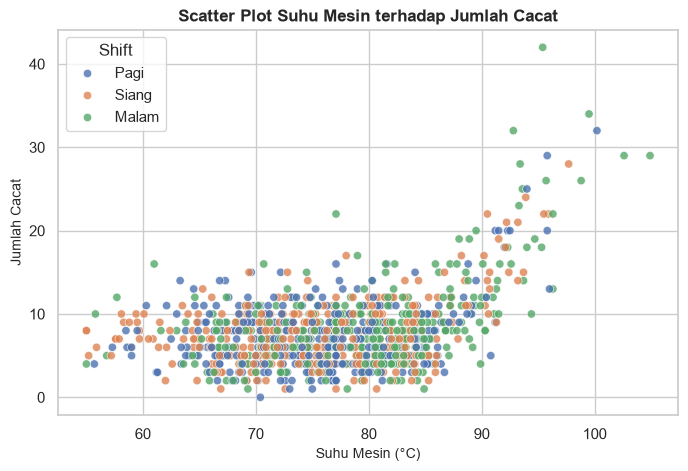

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Suhu_Mesin', y='Jumlah_Cacat', hue='Shift', palette='deep', alpha=0.8)
plt.title('Scatter Plot Suhu Mesin terhadap Jumlah Cacat', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Mesin (°C)', fontsize=10)
plt.ylabel('Jumlah Cacat', fontsize=10)
plt.legend(title='Shift')
plt.show()